
# UMAP on MNIST (via `sklearn.datasets.fetch_openml`)

This notebook:
- Downloads **MNIST** from OpenML using `sklearn.datasets.fetch_openml` (70,000 images, 784 features).
- Runs **UMAP** (`umap-learn` implementation) to get a 2D embedding.
- Plots the embedding colored by digit label.
- Demonstrates **out-of-sample** embedding via `umap.UMAP.transform` on a held-out split.

> Requirements: `scikit-learn`, `umap-learn`, `matplotlib`, `numpy`.


In [1]:

# If umap-learn is not installed, uncomment the next line to install.
# %pip install umap-learn


In [2]:

SEED = 42
SUBSAMPLE = 10000   # set to None for full 70k (will be slower)
N_NEIGHBORS = 15
MIN_DIST = 0.1
N_COMPONENTS = 2    # 2D embedding
TEST_FRACTION = 0.2 # for out-of-sample transform demo


In [3]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

import umap.umap_ as umap

np.random.seed(SEED)


/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float32) / 255.0
y = mnist['target'].astype(int)
print("Full dataset:", X.shape, y.shape)


Full dataset: (70000, 784) (70000,)


In [5]:

if SUBSAMPLE is not None and SUBSAMPLE < X.shape[0]:
    idx = np.random.choice(X.shape[0], SUBSAMPLE, replace=False)
    X = X[idx]
    y = y[idx]
print("Using:", X.shape, y.shape)


Using: (10000, 784) (10000,)


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_FRACTION, random_state=SEED, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (8000, 784)  Test: (2000, 784)


In [7]:
%%time
umap_model = umap.UMAP(
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    n_components=N_COMPONENTS,
    random_state=SEED+5,
    metric='euclidean'
)
Z_train = umap_model.fit_transform(X_train)
print("Embedding shape (train):", Z_train.shape)


/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Embedding shape (train): (8000, 2)
CPU times: user 18.1 s, sys: 771 ms, total: 18.9 s
Wall time: 16 s


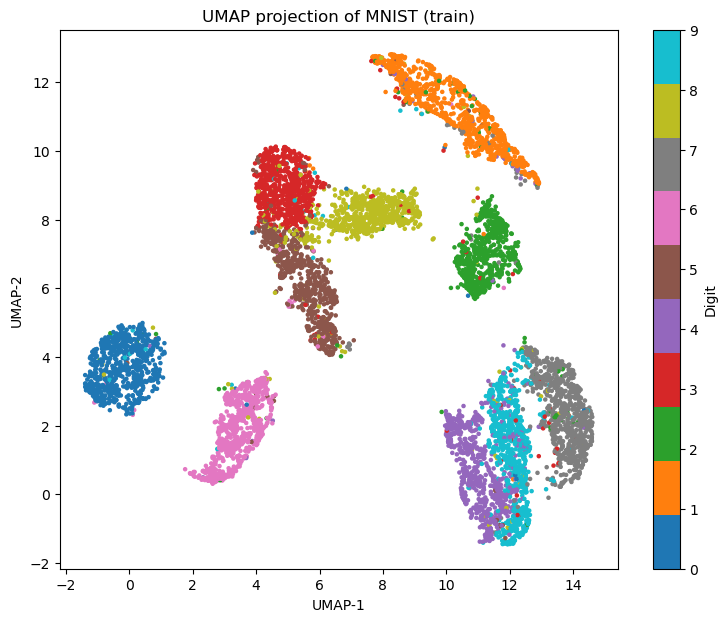

In [8]:

plt.figure(figsize=(9,7))
sc = plt.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=5, cmap="tab10")
plt.title("UMAP projection of MNIST (train)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
cb = plt.colorbar(sc, ticks=range(10))
cb.set_label("Digit")
plt.show()


In [9]:

Z_test = umap_model.transform(X_test)
print("Embedding shape (test):", Z_test.shape)


Embedding shape (test): (2000, 2)


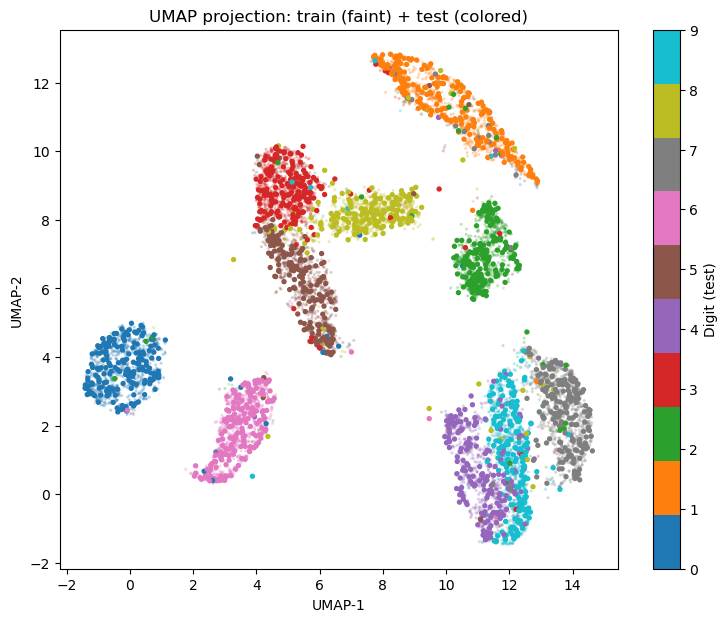

In [10]:

plt.figure(figsize=(9,7))
plt.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=2, alpha=0.2, cmap="tab10")
sc = plt.scatter(Z_test[:,0], Z_test[:,1], c=y_test, s=8, cmap="tab10")
plt.title("UMAP projection: train (faint) + test (colored)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
cb = plt.colorbar(sc, ticks=range(10))
cb.set_label("Digit (test)")
plt.show()



## Notes & Tips
- Use PCA (e.g. 50 dims) before UMAP for speed.
- Try different metrics (`cosine`, `manhattan`) for variety.
- Use `umap_model.transform(new_data)` for out-of-sample points.


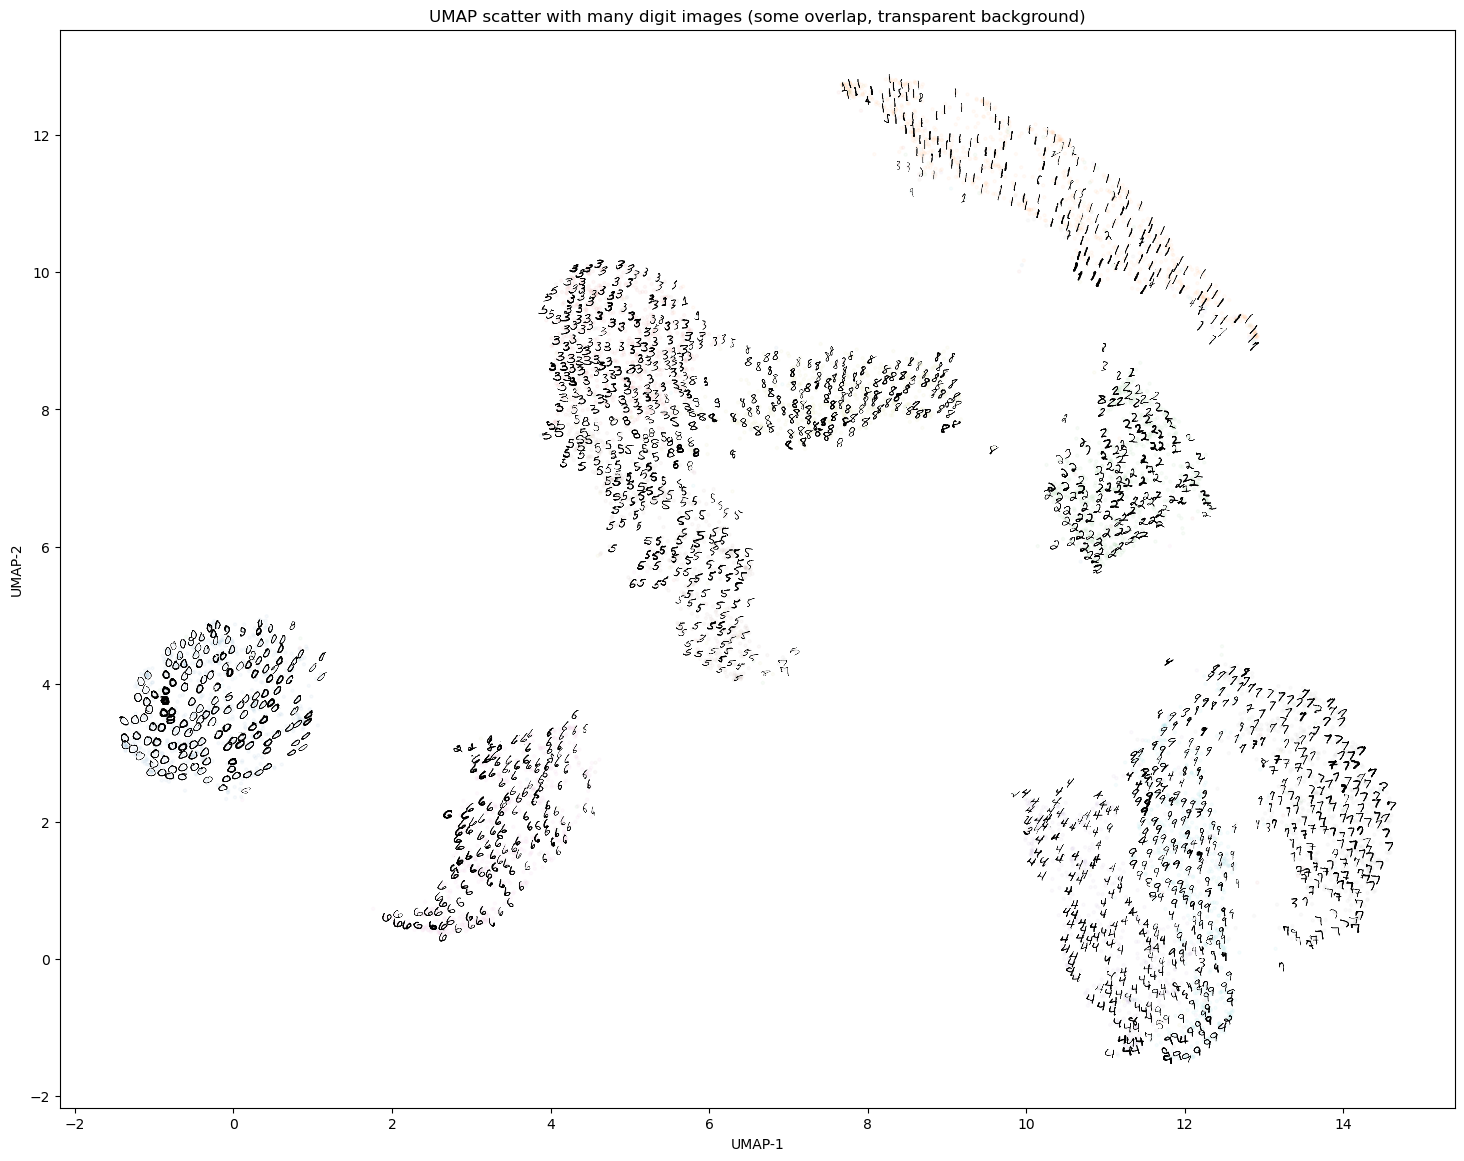

In [12]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

N_ATTEMPT = 4000  # Try to plot up to 4000 digits
MIN_DIST = 0.1    # Allow some overlap (smaller minimum distance)
idx_attempt = np.random.choice(X_train.shape[0], N_ATTEMPT, replace=False)

fig, ax = plt.subplots(figsize=(18, 14))
ax.set_title('UMAP scatter with many digit images (some overlap, transparent background)')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

ax.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=5, alpha=0.03, cmap='tab10')

plotted = []
for i in idx_attempt:
    xy = Z_train[i]
    if plotted:
        dists = np.linalg.norm(np.array(plotted) - xy, axis=1)
        if np.any(dists < MIN_DIST):
            continue  # Skip if too close to any already plotted image
    img = X_train[i].reshape(28, 28)
    img = 1.0 - img
    rgba_img = np.zeros((28, 28, 4))
    rgba_img[..., 0] = img
    rgba_img[..., 1] = img
    rgba_img[..., 2] = img
    rgba_img[..., 3] = (img < 0.95).astype(float)
    imagebox = OffsetImage(rgba_img, zoom=1.0/3.0)
    ab = AnnotationBbox(imagebox, xy, frameon=False)
    ax.add_artist(ab)
    plotted.append(xy)

ax.update_datalim(np.array(plotted))
ax.autoscale_view()
plt.show()

/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


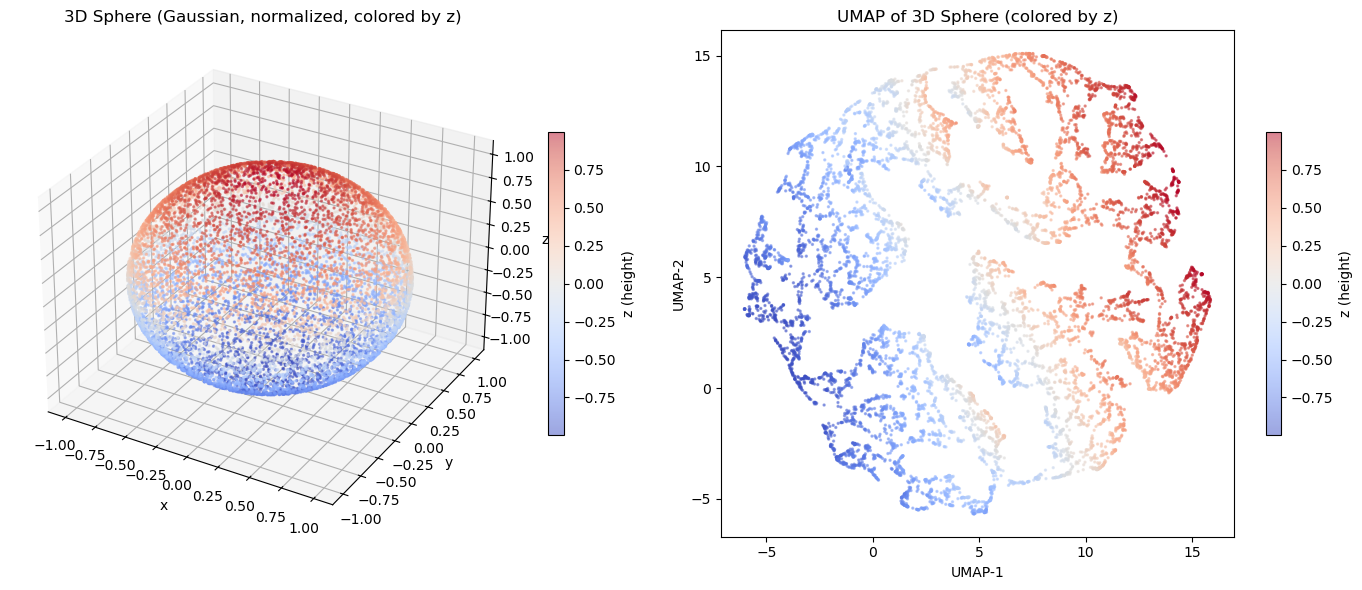

In [6]:
# Generate points on a 3D sphere by sampling from a 3D Gaussian and normalizing, then run UMAP
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from mpl_toolkits.mplot3d import Axes3D

# Parameters
N_SPHERE = 10000  # number of points
SEED_SPHERE = 12
np.random.seed(SEED_SPHERE)

# Generate points from a 3D standard normal and normalize to unit length
X_raw = np.random.randn(N_SPHERE, 3)
X_sphere = X_raw / np.linalg.norm(X_raw, axis=1, keepdims=True)
x, y, z = X_sphere[:,0], X_sphere[:,1], X_sphere[:,2]

# Color by z axis value
colors = z  # color by height on the sphere

# Run UMAP to 2D
umap_sphere = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=SEED_SPHERE)
Z_sphere = umap_sphere.fit_transform(X_sphere)

# Plot side by side
fig = plt.figure(figsize=(14,6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(x, y, z, c=colors, cmap='coolwarm', s=2,alpha=0.5)
ax1.set_title('3D Sphere (Gaussian, normalized, colored by z)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
fig.colorbar(sc1, ax=ax1, shrink=0.6, label='z (height)')

ax2 = fig.add_subplot(1, 2, 2)
sc2 = ax2.scatter(Z_sphere[:,0], Z_sphere[:,1], c=colors, cmap='coolwarm', s=2, alpha=0.5)
ax2.set_title('UMAP of 3D Sphere (colored by z)')
ax2.set_xlabel('UMAP-1')
ax2.set_ylabel('UMAP-2')
fig.colorbar(sc2, ax=ax2, shrink=0.6, label='z (height)')
plt.tight_layout()
plt.show()

/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


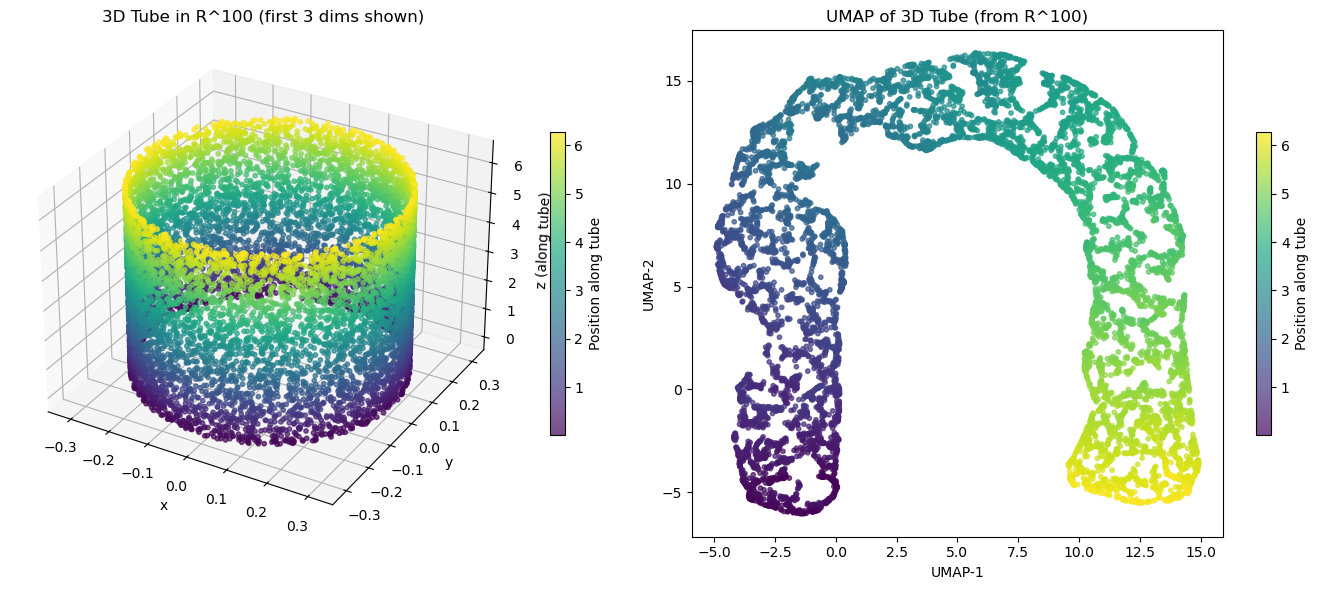

Tube length: 6.28
Tube radius: 0.31
Radius to length ratio: 1:20
Original data shape: (10000, 100)
UMAP embedding shape: (10000, 2)


In [10]:
# Generate data on a 3D tube embedded in R^100 and run UMAP
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from mpl_toolkits.mplot3d import Axes3D

# Parameters
N_TUBE = 10000  # number of points
SEED_TUBE = 456
np.random.seed(SEED_TUBE)

# Tube parameters
tube_length = 2 * np.pi  # Length along the central axis
tube_radius = tube_length / 20  # Radius is 1/20 of the length (ratio 1:20)

# Generate points on a 3D tube
# t: parameter along the central axis (0 to tube_length)
# theta: angle around the tube (0 to 2*pi)
t = np.random.uniform(0, tube_length, N_TUBE)
theta = np.random.uniform(0, 2*np.pi, N_TUBE)

# 3D tube coordinates (tube along z-axis with circular cross-section in x-y plane)
x_tube = tube_radius * np.cos(theta)
y_tube = tube_radius * np.sin(theta)
z_tube = t

# Embed in R^100 by placing the 3D tube in the first 3 dimensions
# and adding small noise to the remaining 97 dimensions
X_tube_3d = np.stack([x_tube, y_tube, z_tube], axis=1)
noise_dims = np.random.normal(0, 0.01, (N_TUBE, 97))  # Small noise in other dimensions
X_tube_100d = np.hstack([X_tube_3d, noise_dims])

# Color by position along the tube (t parameter)
colors = t

# Run UMAP to 2D
umap_tube = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=SEED_TUBE)
Z_tube = umap_tube.fit_transform(X_tube_100d)

# Plot side by side
fig = plt.figure(figsize=(14,6))

# Plot original 3D tube
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(x_tube, y_tube, z_tube, c=colors, cmap='viridis', s=10, alpha=0.7)
ax1.set_title('3D Tube in R^100 (first 3 dims shown)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z (along tube)')
fig.colorbar(sc1, ax=ax1, shrink=0.6, label='Position along tube')

# Plot UMAP embedding
ax2 = fig.add_subplot(1, 2, 2)
sc2 = ax2.scatter(Z_tube[:,0], Z_tube[:,1], c=colors, cmap='viridis', s=10, alpha=0.7)
ax2.set_title('UMAP of 3D Tube (from R^100)')
ax2.set_xlabel('UMAP-1')
ax2.set_ylabel('UMAP-2')
fig.colorbar(sc2, ax=ax2, shrink=0.6, label='Position along tube')

plt.tight_layout()
plt.show()

print(f"Tube length: {tube_length:.2f}")
print(f"Tube radius: {tube_radius:.2f}")
print(f"Radius to length ratio: 1:{tube_length/tube_radius:.0f}")
print(f"Original data shape: {X_tube_100d.shape}")
print(f"UMAP embedding shape: {Z_tube.shape}")

/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


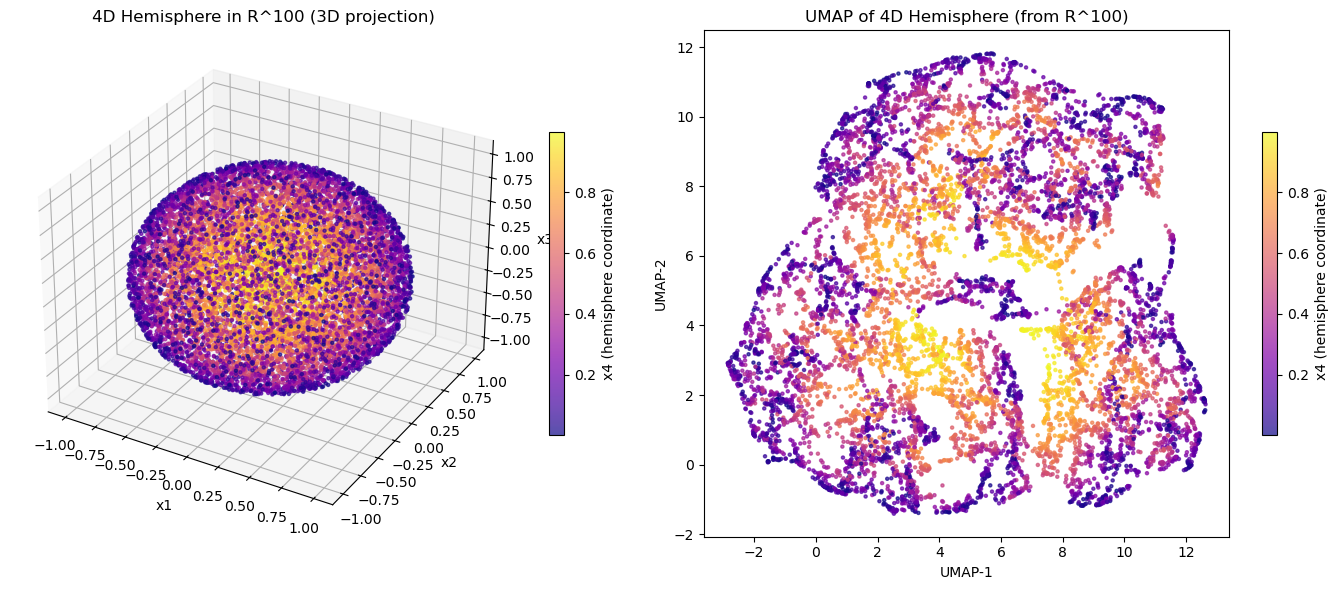

4D Hemisphere points: 10000
4th coordinate range: [0.000, 0.999]
Original data shape: (10000, 100)
UMAP embedding shape: (10000, 2)
All 4th coordinates >= 0: True
Mean distance from origin: 1.000000 (should be ~1.0)


In [16]:
# Generate data on a 4D hemisphere embedded in R^100 and run UMAP
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from mpl_toolkits.mplot3d import Axes3D

# Parameters
N_HEMI = 10000  # number of points
SEED_HEMI = 789
np.random.seed(SEED_HEMI)

# Generate points on a 4D hemisphere by first generating points on a 4D sphere
# then keeping only those with positive 4th coordinate
X_raw = np.random.randn(N_HEMI * 2, 4)  # Generate extra points since we'll filter
X_sphere_4d = X_raw / np.linalg.norm(X_raw, axis=1, keepdims=True)

# Keep only points where the 4th coordinate is positive (hemisphere)
hemisphere_mask = X_sphere_4d[:, 3] >= 0
X_hemisphere_4d = X_sphere_4d[hemisphere_mask][:N_HEMI]  # Take first N_HEMI points

# If we don't have enough points, generate more
while X_hemisphere_4d.shape[0] < N_HEMI:
    X_raw_extra = np.random.randn(N_HEMI, 4)
    X_sphere_extra = X_raw_extra / np.linalg.norm(X_raw_extra, axis=1, keepdims=True)
    hemisphere_mask_extra = X_sphere_extra[:, 3] >= 0
    X_hemisphere_extra = X_sphere_extra[hemisphere_mask_extra]
    X_hemisphere_4d = np.vstack([X_hemisphere_4d, X_hemisphere_extra])

X_hemisphere_4d = X_hemisphere_4d[:N_HEMI]  # Ensure exactly N_HEMI points

# Embed in R^100 by placing the 4D hemisphere in the first 4 dimensions
# and adding small noise to the remaining 96 dimensions
noise_dims = np.random.normal(0, 0.01, (N_HEMI, 96))  # Small noise in other dimensions
X_hemi_100d = np.hstack([X_hemisphere_4d, noise_dims])

# Color by the 4th coordinate (height on hemisphere)
colors = X_hemisphere_4d[:, 3]

# Run UMAP to 2D
umap_hemi = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=SEED_HEMI)
Z_hemi = umap_hemi.fit_transform(X_hemi_100d)

# Plot side by side - show 3D projection of first 3 coordinates
fig = plt.figure(figsize=(14,6))

# Plot 3D projection of the 4D hemisphere (first 3 coordinates)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(X_hemisphere_4d[:,0], X_hemisphere_4d[:,1], X_hemisphere_4d[:,2], 
                  c=colors, cmap='plasma', s=5, alpha=0.7)
ax1.set_title('4D Hemisphere in R^100 (3D projection)')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('x3')
fig.colorbar(sc1, ax=ax1, shrink=0.6, label='x4 (hemisphere coordinate)')

# Plot UMAP embedding
ax2 = fig.add_subplot(1, 2, 2)
sc2 = ax2.scatter(Z_hemi[:,0], Z_hemi[:,1], c=colors, cmap='plasma', s=5, alpha=0.7)
ax2.set_title('UMAP of 4D Hemisphere (from R^100)')
ax2.set_xlabel('UMAP-1')
ax2.set_ylabel('UMAP-2')
fig.colorbar(sc2, ax=ax2, shrink=0.6, label='x4 (hemisphere coordinate)')

plt.tight_layout()
plt.show()

print(f"4D Hemisphere points: {X_hemisphere_4d.shape[0]}")
print(f"4th coordinate range: [{np.min(colors):.3f}, {np.max(colors):.3f}]")
print(f"Original data shape: {X_hemi_100d.shape}")
print(f"UMAP embedding shape: {Z_hemi.shape}")

# Verify it's actually a hemisphere (all 4th coordinates should be >= 0)
print(f"All 4th coordinates >= 0: {np.all(colors >= 0)}")
print(f"Mean distance from origin: {np.mean(np.linalg.norm(X_hemisphere_4d, axis=1)):.6f} (should be ~1.0)")

In [ ]:
# Generate the same 4D hemisphere points and save to CSV
import pandas as pd
import numpy as np

# Use the same parameters as the previous cell
N_HEMI = 10000
SEED_HEMI = 789
np.random.seed(SEED_HEMI)

# Generate points on a 4D hemisphere by first generating points on a 4D sphere
# then keeping only those with positive 4th coordinate
X_raw = np.random.randn(N_HEMI * 2, 4)  # Generate extra points since we'll filter
X_sphere_4d = X_raw / np.linalg.norm(X_raw, axis=1, keepdims=True)

# Keep only points where the 4th coordinate is positive (hemisphere)
hemisphere_mask = X_sphere_4d[:, 3] >= 0
X_hemisphere_4d = X_sphere_4d[hemisphere_mask][:N_HEMI]  # Take first N_HEMI points

# If we don't have enough points, generate more
while X_hemisphere_4d.shape[0] < N_HEMI:
    X_raw_extra = np.random.randn(N_HEMI, 4)
    X_sphere_extra = X_raw_extra / np.linalg.norm(X_raw_extra, axis=1, keepdims=True)
    hemisphere_mask_extra = X_sphere_extra[:, 3] >= 0
    X_hemisphere_extra = X_sphere_extra[hemisphere_mask_extra]
    X_hemisphere_4d = np.vstack([X_hemisphere_4d, X_hemisphere_extra])

X_hemisphere_4d = X_hemisphere_4d[:N_HEMI]  # Ensure exactly N_HEMI points

# Embed in R^100 by placing the 4D hemisphere in the first 4 dimensions
# and adding small noise to the remaining 96 dimensions
noise_dims = np.random.normal(0, 0.01, (N_HEMI, 96))  # Small noise in other dimensions
X_hemi_100d = np.hstack([X_hemisphere_4d, noise_dims])

# Create DataFrame with descriptive column names
# First 4 columns are the hemisphere coordinates, rest are noise dimensions
column_names = ['x1', 'x2', 'x3', 'x4'] + [f'noise_{i+1}' for i in range(96)]
df_hemisphere = pd.DataFrame(X_hemi_100d, columns=column_names)

# Add a column for the hemisphere coordinate (4th dimension)
df_hemisphere['hemisphere_coord'] = X_hemisphere_4d[:, 3]

# Save to CSV
csv_filename = '4d_hemisphere_points.csv'
df_hemisphere.to_csv(csv_filename, index=False)

print(f"Generated {N_HEMI} points on 4D hemisphere embedded in R^100")
print(f"Saved to: {csv_filename}")
print(f"DataFrame shape: {df_hemisphere.shape}")
print(f"4th coordinate range: [{df_hemisphere['x4'].min():.3f}, {df_hemisphere['x4'].max():.3f}]")
print(f"All 4th coordinates >= 0: {(df_hemisphere['x4'] >= 0).all()}")
print(f"Mean distance from origin (4D): {np.mean(np.linalg.norm(X_hemisphere_4d, axis=1)):.6f}")

# Display first few rows
print("\nFirst 5 rows:")
print(df_hemisphere.head())